In [63]:
!pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   -------------- ------------------------- 4.5/11.9 MB 23.0 MB/s eta 0:00:01
   ----------------------------------- ---- 10.5/11.9 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 23.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [tifffile]
   -------------------- ------------------- 2/4 [imageio]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ------------------------------ --------- 3/4 [scikit-image]
   ---------------------------------------- 4/4 [scikit-image]



In [54]:
from PIL import Image
import random
import numpy as np
from pdf2image import convert_from_path
from pathlib import Path
import os
from skimage.filters import threshold_sauvola
import numpy as np

# On crope les images pour enlever le fond

In [55]:
def crop_img(img_path, output_dir):
    img = load_image(img_path)
    file_name = Path(img_path).stem + '.jpg'

    bbox = detect_content_bbox(img)
    if bbox:
        img = img.crop(bbox)

        img_gray = np.array(img.convert("L"))

        thresh = threshold_sauvola(img_gray, window_size=25)
        binary = img_gray > thresh

        binary = (binary * 255).astype("uint8")
        img = Image.fromarray(binary)
    else:
        return
    output_file = os.path.join(output_dir, file_name)
    os.makedirs(output_dir, exist_ok=True)
    img.save(output_file)

In [56]:
def get_page_color(arr, sample_size=75):
    """Couleur du feuillet = centre de l'image."""
    h, w = arr.shape[:2]
    cy, cx = h // 2, w // 2
    s = sample_size // 2
    patch = arr[cy-s:cy+s, cx-s:cx+s]
    return patch.mean(axis=(0, 1))

def detect_content_bbox(img, color_tolerance=10, min_row_ratio=0.06, min_col_ratio=0.06, crop_max=0.6):
    arr = np.array(img.convert("RGB"))
    h, w = arr.shape[:2]

    page_color = get_page_color(arr)

    diff = np.abs(arr.astype(float) - page_color).max(axis=2)
    page_mask = diff < color_tolerance  # True = pixel ressemble au feuillet

    # Proportion de pixels "feuillet" par ligne et par colonne
    row_ratio = page_mask.mean(axis=1)  # shape (h,)
    col_ratio = page_mask.mean(axis=0)  # shape (w,)

    # Une ligne/colonne est "dans le feuillet" si assez de pixels y correspondent
    valid_rows = row_ratio > min_row_ratio
    valid_cols = col_ratio > min_col_ratio

    if not valid_rows.any() or not valid_cols.any():
        return None

    top,  bottom = np.where(valid_rows)[0][[0, -1]]
    left, right  = np.where(valid_cols)[0][[0, -1]]

    # Pas de crop si le feuillet occupe déjà presque toute l'image
    if left < w * 0.05 and top < h * 0.05 and right > w * 0.95 and bottom > h * 0.95:
        return None

    min_w = int(w * crop_max)
    min_h = int(h * crop_max)

    crop_w = right - left
    crop_h = bottom - top

    if crop_w < min_w:
        diff = min_w - crop_w
        left  = max(0, left - diff // 2)
        right = min(w, left + min_w)

    if crop_h < min_h:
        diff = min_h - crop_h
        top    = max(0, top - diff // 2)
        bottom = min(h, top + min_h)
    #margin = 0
    margin = -.07*max(h,w)
    return (
        max(0, left - margin),
        max(0, top - margin),
        min(w, right + margin),
        min(h, bottom + margin)
    )

In [57]:
def load_image(input_path):
    """Charge une image ou un PDF (première page) en objet PIL Image."""
    ext = os.path.splitext(input_path)[1].lower()
    if ext == ".pdf":
        pages = convert_from_path(input_path, dpi=200, first_page=1, last_page=1)
        return pages[0]  # première page uniquement
    else:
        return Image.open(input_path)

In [84]:
crop_img("ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_fullpages_train/Pizan_fullpages_train/PIZAN_002029.jpg", "essai")

In [58]:
input_dir = Path("outiput")
output_dir = Path("res/tasso")
output_dir.mkdir(exist_ok=True)

for img_path in input_dir.iterdir():
    if img_path.is_file():
        crop_img(img_path, output_dir)

In [6]:
input_dir = Path("ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images")
output_dir = Path("ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped_test")
output_dir.mkdir(exist_ok=True)

for img_path in input_dir.iterdir():
    if img_path.is_file():
        crop_img(img_path, output_dir)

In [8]:
input_dir = Path("../2. Torquato Tasso/2. Test dataset with unlabeled images")
output_dir = Path("../2. Torquato Tasso/img_cropped_test")
output_dir.mkdir(exist_ok=True)

for img_path in input_dir.iterdir():
    if img_path.is_file():
        crop_img(img_path, output_dir)

Resultats


In [ ]:
#récupération des embeddings sur les images croppées de test
import os
import torch
import numpy as np
from PIL import Image

from transformers import AutoImageProcessor, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# On retrouve ici le même code que pour Torquato Tasso
folder = "ICDAR(1)/ICDAR/Christine de Pizan/img_cropped_test"
#C:\Users\Comep\Downloads\ICDAR(1)\ICDAR\Christine de Pizan\Test dataset with unlabeled images\images_fullpages_test\images_fullpages_test
#folder2 = "C:/Users/Comep/Downloads/ICDAR(1)/ICDAR/Christine de Pizan/Test dataset with unlabeled images/images_fullpages_test/images_fullpages_test"
folder2 = "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped_test"
folder3="../2. Torquato Tasso/img_cropped_test"
#folder2 = "C:/Users/Comep/Downloads/ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images"
#folder = "Downloads/ICDAR(1)/ICDAR/LESTEST"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_P = []
labels_P = []
for file in os.listdir(folder):
    
    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder, file)

    img = Image.open(path).convert("RGB") # uniformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_P.append(emb)

    # check les noms des labels
    
    labels_P.append(2)
embeddings_Y = []
labels_Y = []

for file in os.listdir(folder2):
    
    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder2, file)

    img = Image.open(path).convert("RGB") # uniformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_Y.append(emb)

    # check les noms des labels
    
    labels_Y.append(2)
embeddings_T = []

labels_T = []

for file in os.listdir(folder3):

    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder3, file)

    img = Image.open(path).convert("RGB") # uniformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_T.append(emb)

    # check les noms des labels
    
    labels_T.append(2)
    
# paramètres de l'array
np.save("embeddings_PTC.npy", embeddings_P)
np.save("laabels_PTC.npy", labels_P)

np.save("embeddings_TTC.npy", embeddings_T)
np.save("laabels_TTC.npy", labels_T)

np.save("embeddings_YTC.npy", embeddings_Y)
np.save("laabels_YTC.npy", labels_Y)



TEST DE LA METHODE TSNE

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

def plot_tsne_train_test(embeddings1, labels1, embeddings2, labels2):
    """
    embeddings1: embeddings for train set (labels 0 and 1)
    labels1: list/array of 0 (true) and 1 (false)
    
    embeddings2: embeddings for test set
    labels2: list/array of 2 only
    """

    # Convert to numpy
    emb1 = np.array(embeddings1)
    emb2 = np.array(embeddings2)

    labels1 = np.array(labels1)
    labels2 = np.array(labels2)

    # Merge
    embeddings_all = np.vstack([emb1, emb2])
    labels_all = np.concatenate([labels1, labels2])

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    points = tsne.fit_transform(embeddings_all)

    # Colors
    color_map = {
        0: "blue",   # true
        1: "red",    # false
        2: "green"   # test
    }
    colors = [color_map[l] for l in labels_all]

    # Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], c=colors)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='0 = true',
               markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='1 = false',
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='2 = test',
               markerfacecolor='green', markersize=8),
    ]
    plt.legend(handles=legend_elements)

    plt.title("t-SNE: Train (true/false) vs Test")
    plt.show()

TEST DE LA METHODE UMAP, AVEC DE MEILLEURS RESULTATS

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from matplotlib.lines import Line2D

def plot_umap_train_test(embeddings1, labels1, embeddings2, labels2, out ="test.png"):
    # Convert to numpy
    emb1 = np.array(embeddings1)
    emb2 = np.array(embeddings2)

    labels1 = np.array(labels1)
    labels2 = np.array(labels2)

    # Fit ONLY on train
    reducer = umap.UMAP(n_components=2, random_state=42)
    reducer.fit(emb1)

    # Transform
    train_2d = reducer.transform(emb1)
    test_2d = reducer.transform(emb2)

    # Color map
    color_map = {
        0: "blue",   # true
        1: "red",    # false
        2: "green"   # test
    }

    # Plot
    plt.figure(figsize=(8, 8))

    # 👉 Train points (normal)
    plt.scatter(train_2d[:, 0], train_2d[:, 1],
                c=[color_map[l] for l in labels1],
                alpha=0.8,
                s=40,
                marker='o',
                zorder=2)

    # 👉 Test points (transparent + different marker)
    plt.scatter(test_2d[:, 0], test_2d[:, 1],
                c="green",
                alpha=0.4,
                s=25,
                marker='x',   # 👈 key difference
                zorder=1)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='0 = true',
               markerfacecolor='blue', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='1 = false',
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='x', color='green', label='2 = test',
               markersize=8),
    ]
    plt.legend(handles=legend_elements)

    plt.title("UMAP: Train (true/false) + Test (projected)")
    plt.savefig(out) 
    plt.show()
    #plt.savefig(out) 

In [2]:
EP_O_Tr =np.load("embeddings_P_o.npy")
EP_O_Te =np.load("embeddings_P_t.npy")

EP_C_Tr =np.load("embeddings_P.npy")
EP_C_Te =np.load("embeddings_PTC.npy")

##
ET_O_Tr =np.load("embeddings_T_o.npy")
ET_O_Te =np.load("embeddings_T_t.npy")

ET_C_Tr =np.load("embeddings_T.npy")
ET_C_Te =np.load("embeddings_TTC.npy")

##
EY_O_Tr =np.load("embeddings_Y_o.npy")
EY_O_Te =np.load("embeddings_Y_t.npy")

E_Y_Tr =np.load("embeddings_Y.npy")
E_Y_Te =np.load("embeddings_YTC.npy")

##
##
LP_O_Tr =np.load("laabels_P_o.npy")
LP_O_Te =np.load("laabels_P_t.npy")

LP_C_Tr =np.load("laabels_P.npy")
LP_C_Te =np.load("laabels_PTC.npy")

##
LT_O_Tr =np.load("laabels_T_o.npy")
LT_O_Te =np.load("laabels_T_t.npy")

LT_C_Tr =np.load("laabels_T.npy")
LT_C_Te =np.load("laabels_TTC.npy")

##
LY_O_Tr =np.load("laabels_Y_o.npy")
LY_O_Te =np.load("laabels_Y_t.npy")

L_Y_Tr =np.load("laabels_Y.npy")
L_Y_Te =np.load("laabels_YTC.npy")
POL =np.load("embeddings_P_o_l.npy")
PLOL=np.load("laabels_P_o_l.npy")
Pipo =np.load("embeddings_P_O_L_T.npy")
Popipo=np.load("laabels_P_O_L_T.npy")

In [17]:
POL =np.load("embeddings_P_o_l.npy")
PLOL=np.load("laabels_P_o_l.npy")
Pipo =np.load("embeddings_P_O_L_T.npy")
Popipo=np.load("laabels_P_O_L_T.npy")

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


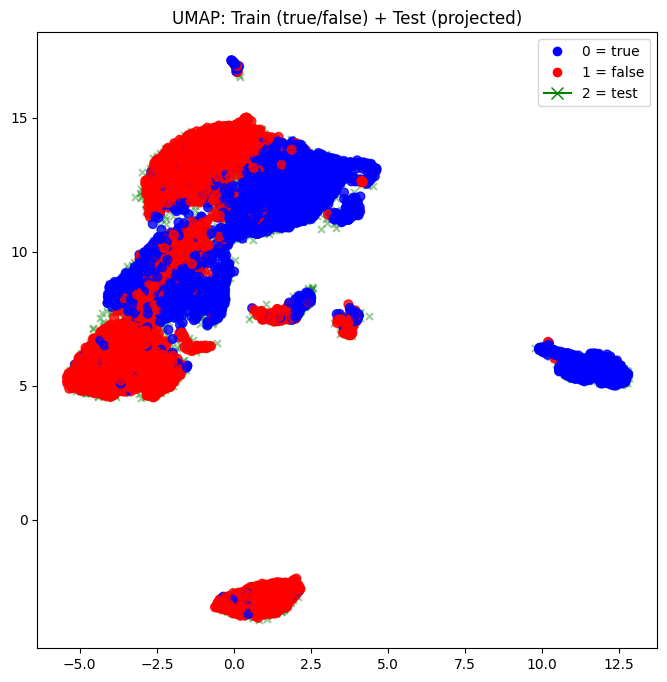

In [18]:
plot_umap_train_test(POL,PLOL,Pipo, Popipo, out="res/pizan_lines.png" )

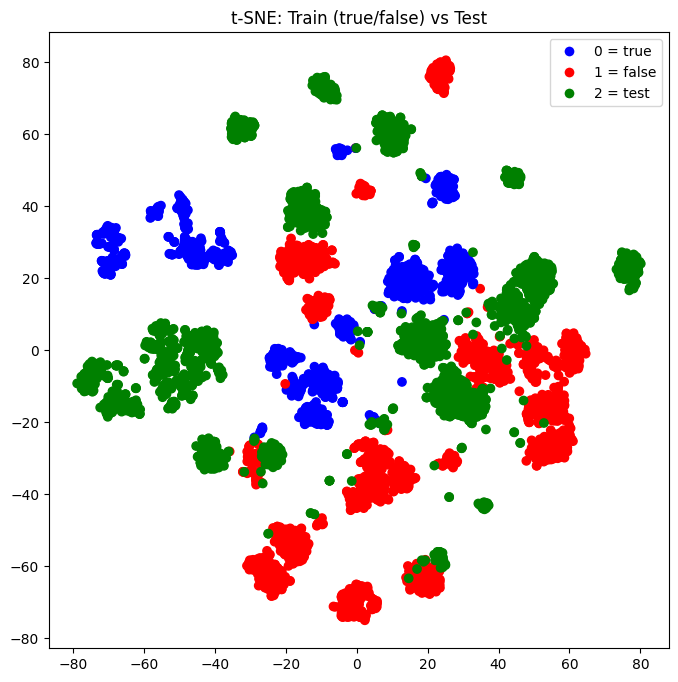

In [4]:
plot_tsne_train_test(EP_O_Tr,LP_O_Tr,EP_O_Te, LP_O_Te )

Il y a 302 vrai et 228 faux donc il faut ajouter 30% de faux donc tous les 3 faux on double la mosaïque


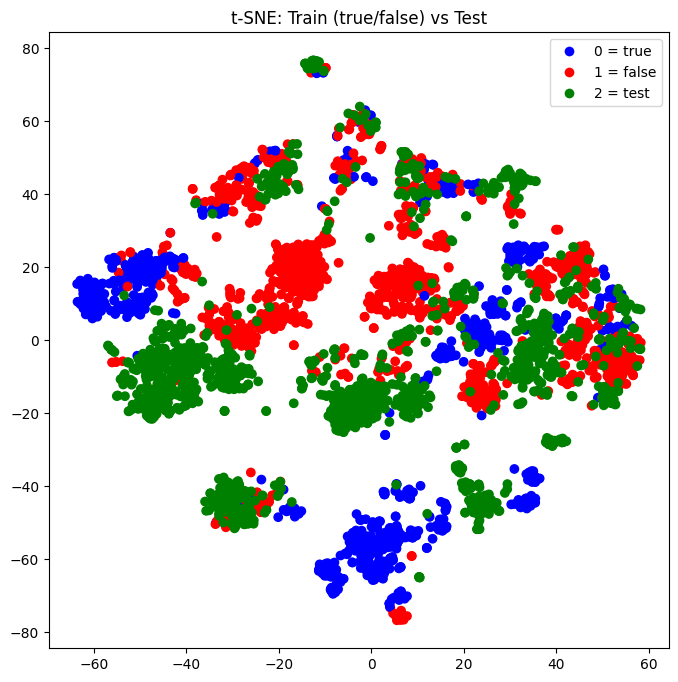

In [5]:
plot_tsne_train_test(EP_C_Tr,LP_C_Tr,EP_C_Te, LP_C_Te )

In [20]:
###pizan

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


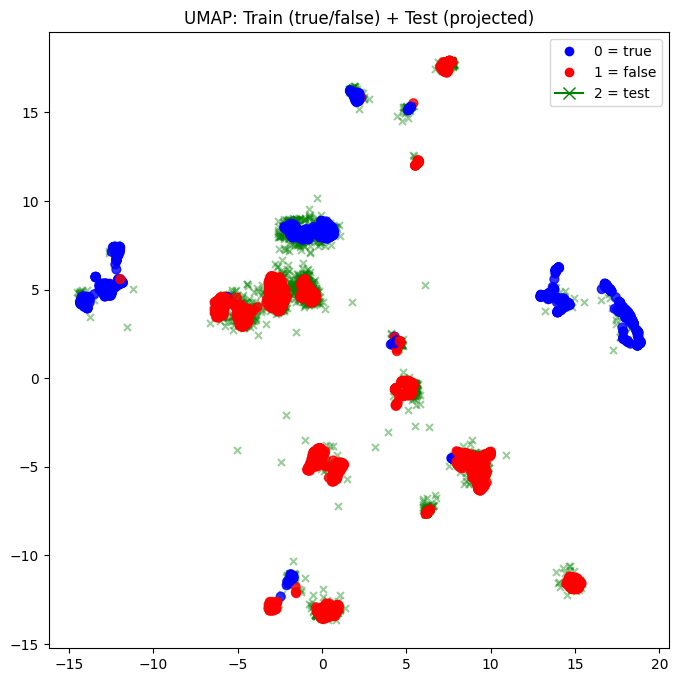

In [10]:
plot_umap_train_test(EP_O_Tr,LP_O_Tr,EP_O_Te, LP_O_Te, out="res/pizan.png" )
#christine de pizan sans crop

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


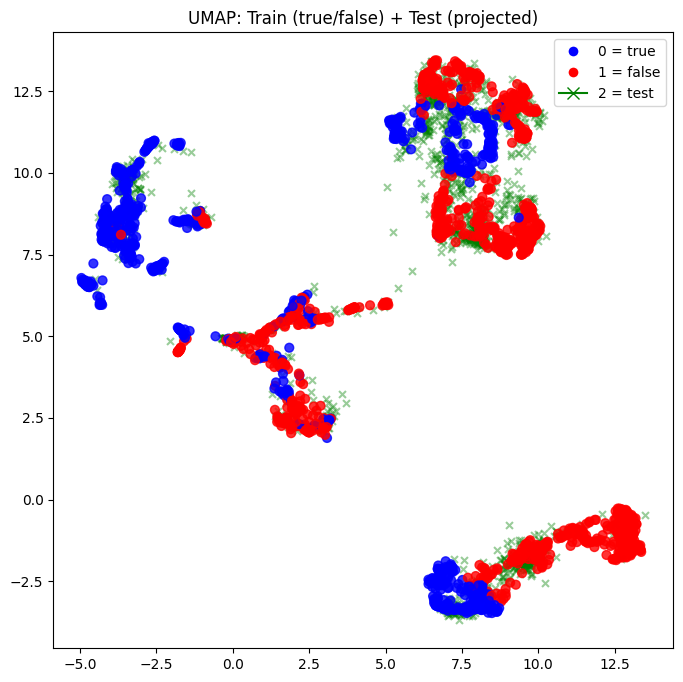

In [11]:
plot_umap_train_test(EP_C_Tr,LP_C_Tr,EP_C_Te, LP_C_Te , out="res/pizan_crop.png" )
#christine de pizan avec crop

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


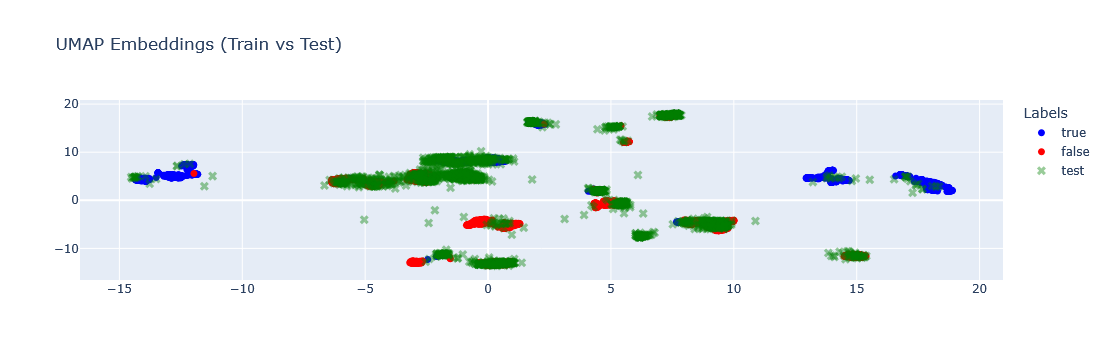

In [28]:
plot_umap_from_precomputed(EP_O_Tr,LP_O_Tr,"ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_fullpages_train/Pizan_fullpages_train",EP_O_Te, LP_O_Te ,"ICDAR(1)/ICDAR/Christine de Pizan/Test dataset with unlabeled images/images_fullpages_test/images_fullpages_test", output_file = "res/Emb_Pizan_original.html")

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


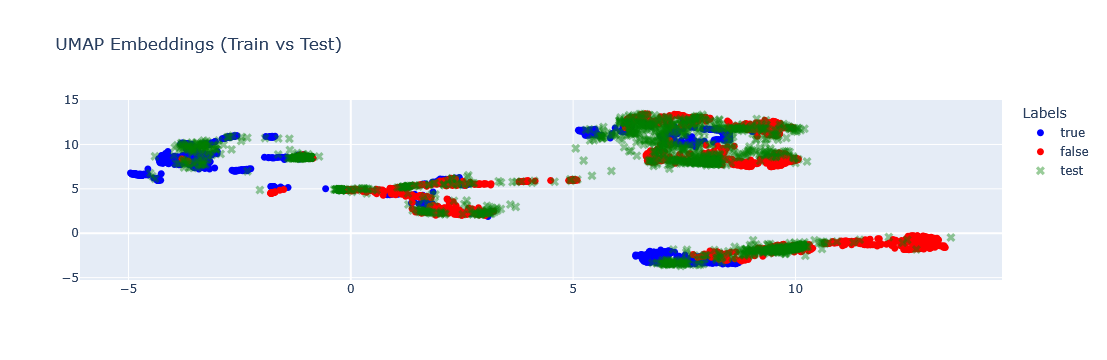

In [29]:
plot_umap_from_precomputed(EP_C_Tr,LP_C_Tr,"ICDAR(1)/ICDAR/Christine de Pizan/img_cropped",EP_C_Te, LP_C_Te,"ICDAR(1)/ICDAR/Christine de Pizan/img_cropped_test", output_file = "res/Emb_Pizan_cropped.html")


In [19]:
####yaqut

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


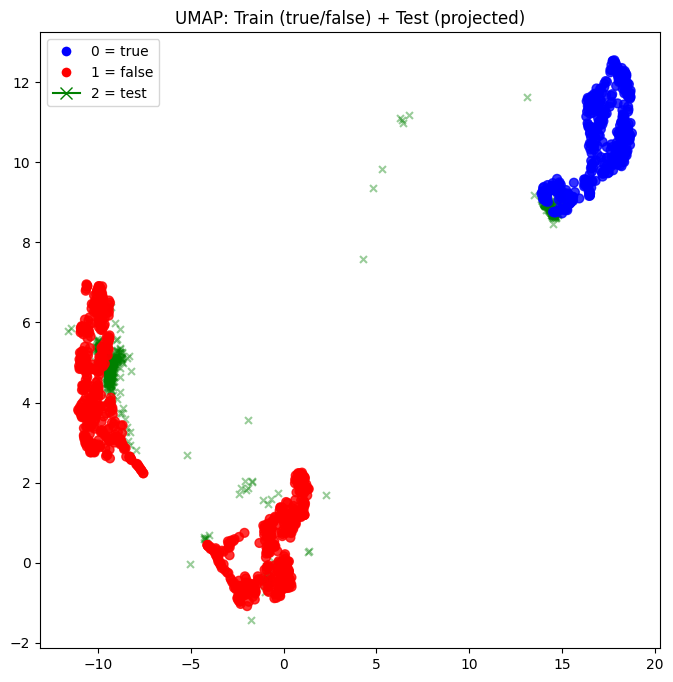

In [30]:
plot_umap_train_test(EY_O_Tr,LY_O_Tr,EY_O_Te, LY_O_Te, out="res/yaqut.png"  )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


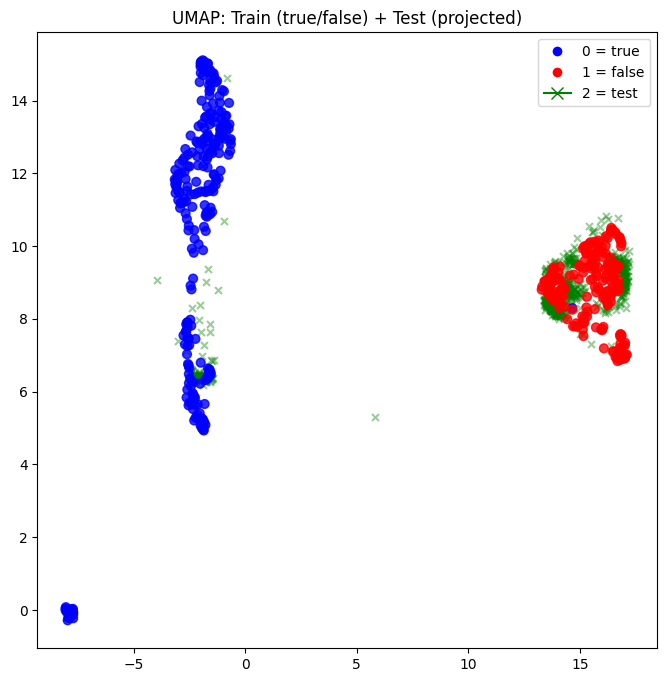

In [13]:
plot_umap_train_test(E_Y_Tr,L_Y_Tr,E_Y_Te, L_Y_Te , out="res/yaqut_crop.png" )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


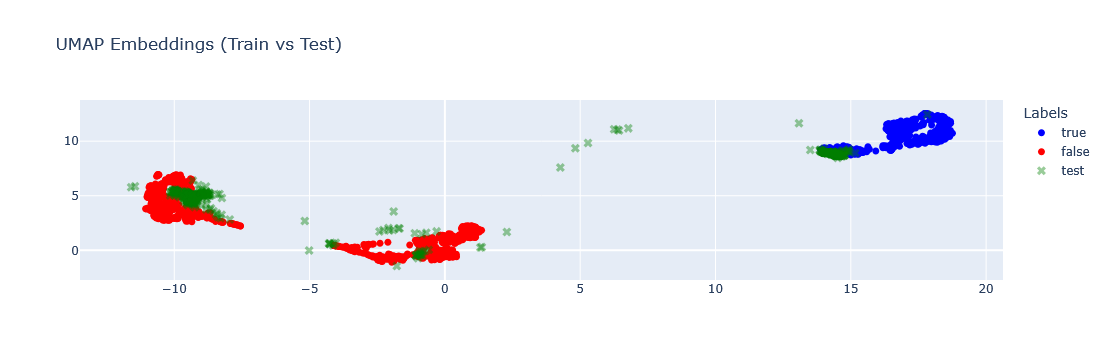

In [33]:
plot_umap_from_precomputed(EY_O_Tr,LY_O_Tr,"ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/1. Training dataset with images labeled as authentic or fake",EY_O_Te, LY_O_Te,"ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images",output_file = "res/Emb_Yaqut_original.html")


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


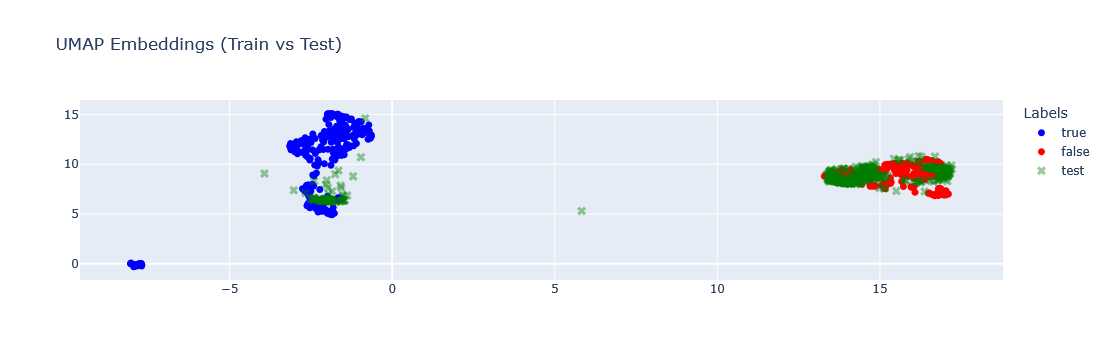

In [32]:
plot_umap_from_precomputed(E_Y_Tr,L_Y_Tr,"ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped",E_Y_Te, L_Y_Te,"ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped_test",output_file = "res/Emb_Yaqut_cropped.html")


In [18]:
####torquato

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


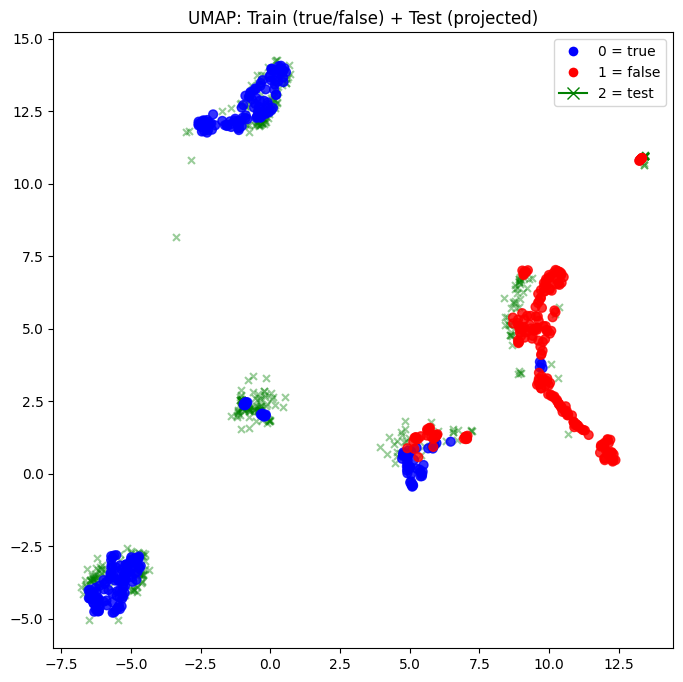

In [14]:
plot_umap_train_test(ET_O_Tr,LT_O_Tr,ET_O_Te, LT_O_Te , out="res/torquato.png" )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


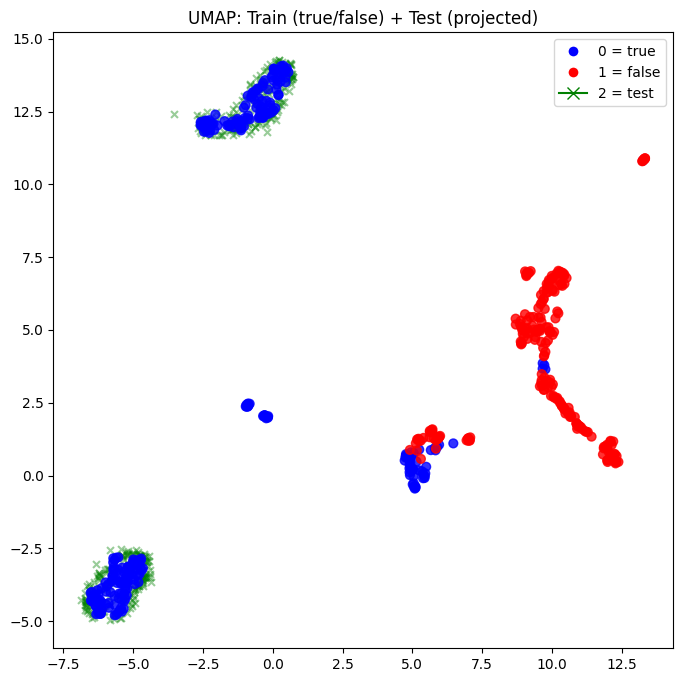

In [60]:
torq298 =np.load("embeddings_P_ExtraSauce.npy")
l = np.load("laabels_P_ExtraSauce.npy")
plot_umap_train_test(ET_O_Tr,LT_O_Tr,torq298, l , out="res/torquato_PDF298.png" )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


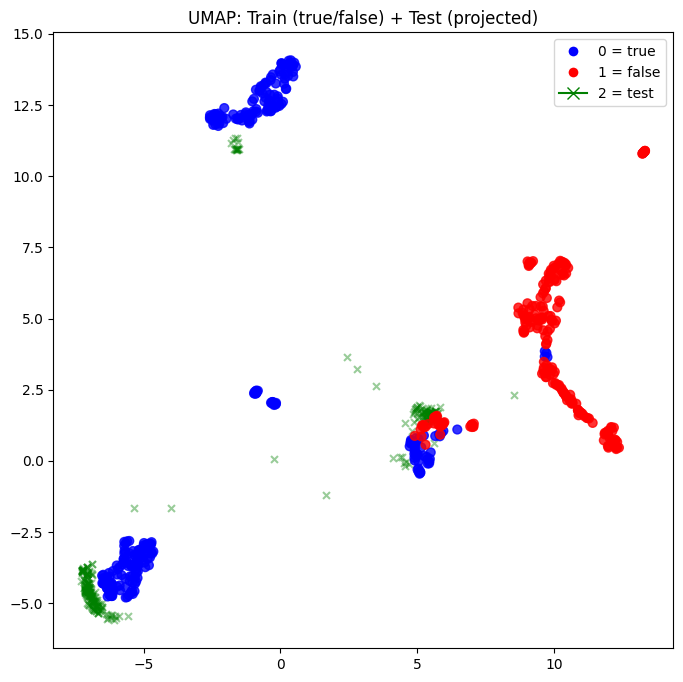

In [61]:
torq298C =np.load("embeddings_P_ExtraSauceDoubleSauce.npy")
lC= np.load("laabels_P_ExtraSauceDoubleSauce.npy")
plot_umap_train_test(ET_O_Tr,LT_O_Tr,torq298C, lC , out="res/torquato_PDF298_cropped.png" )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


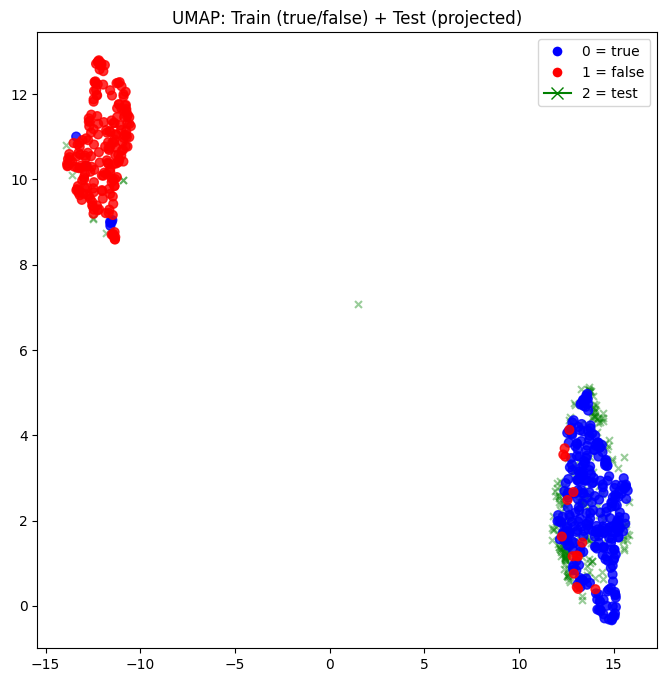

In [15]:
plot_umap_train_test(ET_C_Tr,LT_C_Tr,ET_C_Te, LT_C_Te, out="res/torquato_crop.png"  )


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


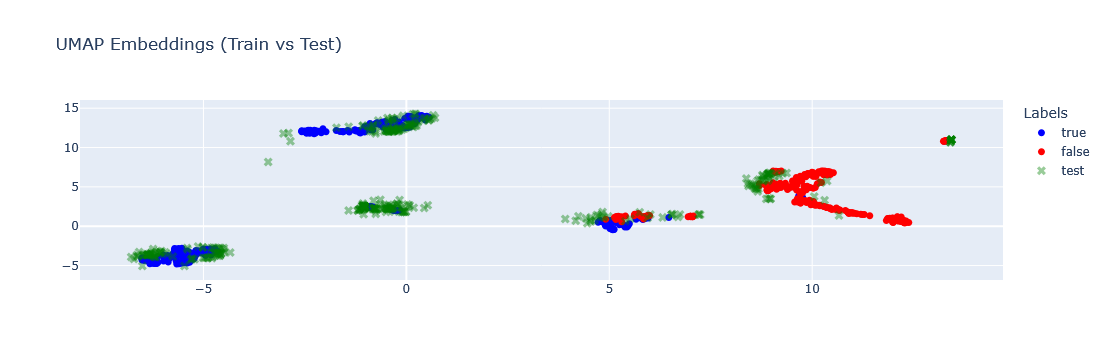

In [42]:
plot_umap_from_precomputed(ET_O_Tr,LT_O_Tr,"../2. Torquato Tasso/datasets/train",ET_O_Te, LT_O_Te,"../2. Torquato Tasso/datasets/test", output_file = "res/Emb_Torquato_original.html")


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


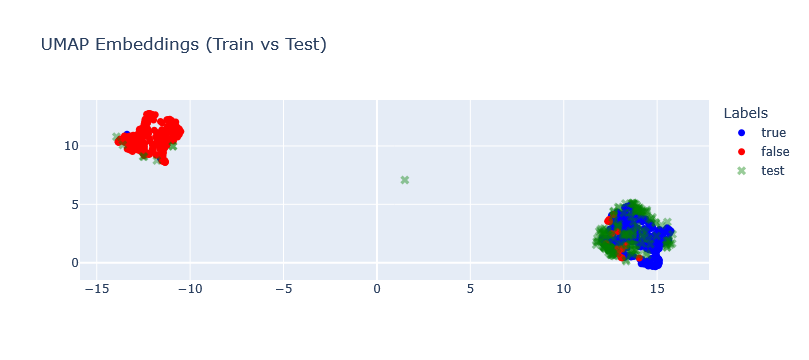

In [42]:
plot_umap_from_precomputed(ET_C_Tr,LT_C_Tr,"../2. Torquato Tasso/img_cropped",ET_C_Te, LT_C_Te,"../2. Torquato Tasso/img_cropped_test", output_file = "res/Emb_Torquato_cropped.html")


In [20]:
len(ET_C_Tr)

509

In [32]:
#extraction des images
import os
import numpy as np
import pandas as pd
import umap.umap_ as umap
import plotly.express as px
import plotly.graph_objects as go
def plot_umap_from_precomputed(
    emb_train, labels_train, train_folder,
    emb_test, labels_test, test_folder,output_file ="ah.html"
):
   # -------- NAMES --------
    def get_names(folder):
        return np.array([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ])

    names_train = get_names(train_folder)
    names_test = get_names(test_folder)

    # -------- UMAP --------
    reducer = umap.UMAP(n_components=2, random_state=42)
    reducer.fit(emb_train)

    train_2d = reducer.transform(emb_train)
    test_2d = reducer.transform(emb_test)

    # -------- SPLIT LABELS --------
    train_labels = np.array(labels_train)
    test_labels = np.array(labels_test)

    # -------- FIG --------
    fig = go.Figure()

    # TRUE (blue)
    mask_true = train_labels == 0
    fig.add_trace(go.Scatter(
        x=train_2d[mask_true, 0],
        y=train_2d[mask_true, 1],
        mode="markers",
        name="true",
        marker=dict(color="blue", symbol="circle", size=7),
        text=names_train[mask_true],
        hovertext=names_train[mask_true]
    ))

    # FALSE (red)
    mask_false = train_labels == 1
    fig.add_trace(go.Scatter(
        x=train_2d[mask_false, 0],
        y=train_2d[mask_false, 1],
        mode="markers",
        name="false",
        marker=dict(color="red", symbol="circle", size=7),
        text=names_train[mask_false]
    ))

    # TEST (green, transparent + different shape)
    fig.add_trace(go.Scatter(
        x=test_2d[:, 0],
        y=test_2d[:, 1],
        mode="markers",
        name="test",
        marker=dict(
            color="green",
            symbol="x",
            size=8,
            opacity=0.4   # 👈 transparency here
        ),
        text=names_test
    ))

    fig.update_layout(
        title="UMAP Embeddings (Train vs Test)",
        legend_title="Labels"
    )

    fig.write_html(output_file)
    fig.show()

In [13]:
len(labels_Y)

0

In [21]:
EP_O_Tr =np.load("embeddings_P_o.npy")
EP_O_Te =np.load("embeddings_P_t.npy")

EP_C_Tr =np.load("embeddings_P.npy")
EP_C_Te =np.load("embeddings_PTC.npy")

##
ET_O_Tr =np.load("embeddings_T_o.npy")
ET_O_Te =np.load("embeddings_T_t.npy")

ET_C_Tr =np.load("embeddings_T.npy")
ET_C_Te =np.load("embeddings_TTC.npy")

##
EY_O_Tr =np.load("embeddings_Y_o.npy")
EY_O_Te =np.load("embeddings_Y_t.npy")

E_Y_Tr =np.load("embeddings_Y.npy")
E_Y_Te =np.load("embeddings_YTC.npy")

##
##
LP_O_Tr =np.load("laabels_P_o.npy")
LP_O_Te =np.load("laabels_P_t.npy")

LP_C_Tr =np.load("laabels_P.npy")
LP_C_Te =np.load("laabels_PTC.npy")

##
LT_O_Tr =np.load("laabels_T_o.npy")
LT_O_Te =np.load("laabels_T_t.npy")

LT_C_Tr =np.load("laabels_T.npy")
LT_C_Te =np.load("laabels_TTC.npy")

##
LY_O_Tr =np.load("laabels_Y_o.npy")
LY_O_Te =np.load("laabels_Y_t.npy")

L_Y_Tr =np.load("laabels_Y.npy")
L_Y_Te =np.load("laabels_YTC.npy")
POL =np.load("embeddings_P_o_l.npy")
PLOL=np.load("laabels_P_o_l.npy")
Pipo =np.load("embeddings_P_O_L_T.npy")
Popipo=np.load("laabels_P_O_L_T.npy")


In [28]:
from sklearn.metrics.pairwise import cosine_distances
import os
import pandas as pd
def fun(embeddings, folder,out):
    def get_names(folder):
        return np.array([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ])

    image_names = get_names(folder)
    D = cosine_distances(embeddings)
    df = pd.DataFrame(D, index=image_names, columns=image_names)
    df.to_csv(out)

In [29]:
fun(EP_O_Tr,"ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_fullpages_train/Pizan_fullpages_train","res/pairwise_distances_pizan_train.csv")



In [34]:

fun(EP_O_Te,"ICDAR(1)/ICDAR/Christine de Pizan/Test dataset with unlabeled images/images_fullpages_test/images_fullpages_test","res/pairwise_distances_pizan_test.csv")



In [37]:


fun(EP_C_Tr,"ICDAR(1)/ICDAR/Christine de Pizan/img_cropped","res/pairwise_distances_pizan_train_cropped.csv")


In [38]:


fun(EP_C_Te,"ICDAR(1)/ICDAR/Christine de Pizan/img_cropped_test","res/pairwise_distances_pizan_test_cropped.csv")


In [39]:

fun(ET_O_Tr,"../2. Torquato Tasso/datasets/train" ,"res/pairwise_distances_torquato_train.csv" )


In [41]:

fun(ET_O_Te,"../2. Torquato Tasso/datasets/test" ,"res/pairwise_distances_torquato_test.csv" )



In [43]:

fun(ET_C_Tr,"../2. Torquato Tasso/img_cropped" ,"res/pairwise_distances_torquato_train_cropped.csv" )



In [44]:

fun(ET_C_Te,"../2. Torquato Tasso/img_cropped_test" ,"res/pairwise_distances_torquato_test_cropped.csv" )



In [49]:
fun(EY_O_Tr

ValueError: Shape of passed values is (1180, 1180), indices imply (463, 463)

In [47]:

fun(EY_O_Te, "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped_test" ,"res/pairwise_distances_yaqut_test.csv" )



In [50]:

fun(E_Y_Tr, "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped" ,"res/pairwise_distances_yaqut_train_cropped.csv" )



In [51]:

fun(E_Y_Te, "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped_test" ,"res/pairwise_distances_yaqut_test_cropped.csv" )



In [52]:
POL =np.load("embeddings_P_o_l.npy")
Pipo =np.load("embeddings_P_O_L_T.npy")

fun(POL, "ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_line_train/Pizan_line_train" ,"res/pairwise_distances_pizan_train_lines.csv" )
fun(Pipo, "ICDAR(1)/ICDAR/Christine de Pizan/Test dataset with unlabeled images/images_snippets_test/images_snippets_test" ,"res/pairwise_distances_pizan_test_lines.csv" )

fun(POL, "" ,"res/pairwise_distances_pizan_train_lines.csv" )

outiput
res/tasso



In [ ]:
"ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images"
EY_O_Tr =np.load("embeddings_Y_o.npy")
EY_O_Te =np.load("embeddings_Y_t.npy")

E_Y_Tr =np.load("embeddings_Y.npy")
E_Y_Te =np.load("embeddings_YTC.npy")



